In [1]:
!pip install -q ultralytics opencv-python matplotlib tqdm pyyaml
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os
import cv2
import yaml
import time
import zipfile
import shutil
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
zip_path = "/content/TILDA Fabric.v1-final.yolov8 (2).zip"

raw_dataset = Path("/content/tilda_raw")
detect_dataset = Path("/content/tilda_yolov8_detect")

if raw_dataset.exists():
    shutil.rmtree(raw_dataset)

if detect_dataset.exists():
    shutil.rmtree(detect_dataset)

print("Paths ready")

Paths ready


In [4]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(raw_dataset)

print("Extracted files:")
print(os.listdir(raw_dataset))

Extracted files:
['train', 'README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'test']


In [5]:
shutil.copytree(raw_dataset, detect_dataset)

for split in ["train", "valid", "test"]:
    image_dir = detect_dataset / split / "images"
    label_dir = detect_dataset / split / "labels"

    print(f"\n{split}")
    print("Images:", len(list(image_dir.glob("*"))))
    print("Labels:", len(list(label_dir.glob("*.txt"))))


train
Images: 280
Labels: 280

valid
Images: 80
Labels: 80

test
Images: 40
Labels: 40


In [6]:
sample_label = None

for txt in (detect_dataset / "train" / "labels").glob("*.txt"):
    content = txt.read_text().strip()
    if content:
        sample_label = txt
        print("Sample label file:", txt)
        print(content[:500])
        break

if sample_label is None:
    print("No non-empty label file found.")
else:
    first_line = sample_label.read_text().strip().splitlines()[0]
    values = first_line.split()

    print("\nNumber of values in first line:", len(values))

    if len(values) == 5:
        print("Correct: YOLO detection bbox format")
    elif len(values) > 5:
        print("Warning: This looks like segmentation polygon format, not detection format")
    else:
        print("Warning: Invalid label format")

Sample label file: /content/tilda_yolov8_detect/train/labels/c1r3e3n24_jpg.rf.1ba062c7f898c34eb3245fe12e312bd1.txt
3 0.4934895833333333 0.5126953125 0.12760416666666666 0.873046875

Number of values in first line: 5
Correct: YOLO detection bbox format


In [7]:
def apply_clahe_bilateral(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l_clahe = clahe.apply(l)
    lab_clahe = cv2.merge((l_clahe, a, b))
    clahe_image = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

    filtered_image = cv2.bilateralFilter(
        clahe_image,
        d=9,
        sigmaColor=75,
        sigmaSpace=75
    )

    return filtered_image


def preprocess_split(split):
    image_dir = detect_dataset / split / "images"

    image_paths = (
        list(image_dir.glob("*.jpg")) +
        list(image_dir.glob("*.jpeg")) +
        list(image_dir.glob("*.png"))
    )

    for image_path in tqdm(image_paths, desc=f"Preprocessing {split}"):
        image = cv2.imread(str(image_path))

        if image is None:
            print("Could not read:", image_path)
            continue

        processed = apply_clahe_bilateral(image)
        cv2.imwrite(str(image_path), processed)


for split in ["train", "valid", "test"]:
    preprocess_split(split)

print("Preprocessing completed")

Preprocessing test: 100%|██████████| 40/40 [00:03<00:00, 12.43it/s]

Preprocessing completed


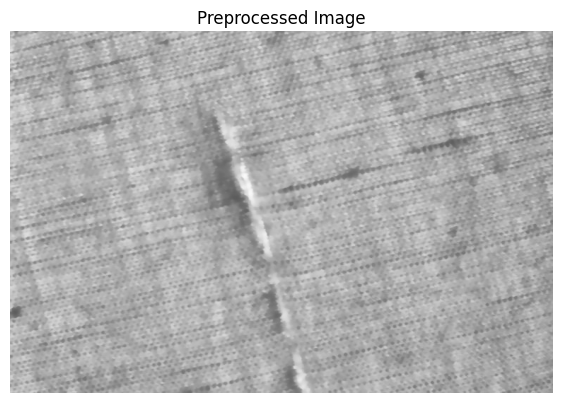

In [8]:
sample_img_path = random.choice(list((detect_dataset / "train" / "images").glob("*")))

image = cv2.imread(str(sample_img_path))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7, 7))
plt.imshow(image_rgb)
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

In [9]:
def read_bbox_label(label_path):
    objects = []

    if not label_path.exists():
        return objects

    lines = label_path.read_text().strip().splitlines()

    for line in lines:
        values = line.split()

        if len(values) != 5:
            continue

        class_id = int(float(values[0]))
        x, y, w, h = map(float, values[1:])

        objects.append({
            "class_id": class_id,
            "x": x,
            "y": y,
            "w": w,
            "h": h
        })

    return objects


def save_bbox_label(label_path, objects):
    lines = []

    for obj in objects:
        line = (
            f"{obj['class_id']} "
            f"{obj['x']:.6f} "
            f"{obj['y']:.6f} "
            f"{obj['w']:.6f} "
            f"{obj['h']:.6f}"
        )
        lines.append(line)

    label_path.write_text("\n".join(lines))

In [10]:
import cv2
from pathlib import Path
from tqdm import tqdm

train_image_dir = Path("/content/tilda_yolov8_detect/train/images")
train_label_dir = Path("/content/tilda_yolov8_detect/train/labels")


def read_bbox_label(label_path):
    objects = []
    if not label_path.exists():
        return objects
    for line in label_path.read_text().strip().splitlines():
        values = line.split()
        if len(values) != 5:
            continue
        class_id = int(float(values[0]))
        x, y, w, h = map(float, values[1:])
        objects.append({"class_id": class_id, "x": x, "y": y, "w": w, "h": h})
    return objects


def save_bbox_label(label_path, objects):
    lines = []
    for obj in objects:
        lines.append(
            f"{obj['class_id']} {obj['x']:.6f} {obj['y']:.6f} "
            f"{obj['w']:.6f} {obj['h']:.6f}"
        )
    label_path.write_text("\n".join(lines))


def horizontal_flip_bbox(objects):
    return [{**obj, "x": 1 - obj["x"]} for obj in objects]

def vertical_flip_bbox(objects):
    return [{**obj, "y": 1 - obj["y"]} for obj in objects]

def rotate_180_bbox(objects):
    return [{**obj, "x": 1 - obj["x"], "y": 1 - obj["y"]} for obj in objects]


# Only original images — strictly filter augmented ones
all_images = (
    list(train_image_dir.glob("*.jpg")) +
    list(train_image_dir.glob("*.jpeg")) +
    list(train_image_dir.glob("*.png"))
)

original_images = [
    p for p in all_images
    if "_hflip" not in p.stem
    and "_vflip" not in p.stem
    and "_rot180" not in p.stem
]

print(f"Original training images: {len(original_images)}")
print(f"Expected total after augmentation: {len(original_images) * 4}")

augmentations = {
    "hflip":  (lambda img: cv2.flip(img, 1),                 horizontal_flip_bbox),
    "vflip":  (lambda img: cv2.flip(img, 0),                 vertical_flip_bbox),
    "rot180": (lambda img: cv2.rotate(img, cv2.ROTATE_180),  rotate_180_bbox),
}

for image_path in tqdm(original_images, desc="Augmenting train set"):
    label_path = train_label_dir / f"{image_path.stem}.txt"
    image = cv2.imread(str(image_path))
    if image is None:
        continue
    objects = read_bbox_label(label_path)
    if not objects:
        continue

    for aug_name, (img_fn, lbl_fn) in augmentations.items():
        new_img_path   = train_image_dir / f"{image_path.stem}_{aug_name}{image_path.suffix}"
        new_label_path = train_label_dir / f"{image_path.stem}_{aug_name}.txt"

        if new_img_path.exists():   # skip if already done
            continue

        cv2.imwrite(str(new_img_path), img_fn(image))
        save_bbox_label(new_label_path, lbl_fn(objects))

final_images = (
    list(train_image_dir.glob("*.jpg")) +
    list(train_image_dir.glob("*.jpeg")) +
    list(train_image_dir.glob("*.png"))
)
print(f"\nFinal train images : {len(final_images)}")
print(f"Final train labels : {len(list(train_label_dir.glob('*.txt')))}")

Original training images: 280
Expected total after augmentation: 1120


Augmenting train set: 100%|██████████| 280/280 [00:02<00:00, 108.32it/s]



Final train images : 1120
Final train labels : 1120


Augmented images found: 840


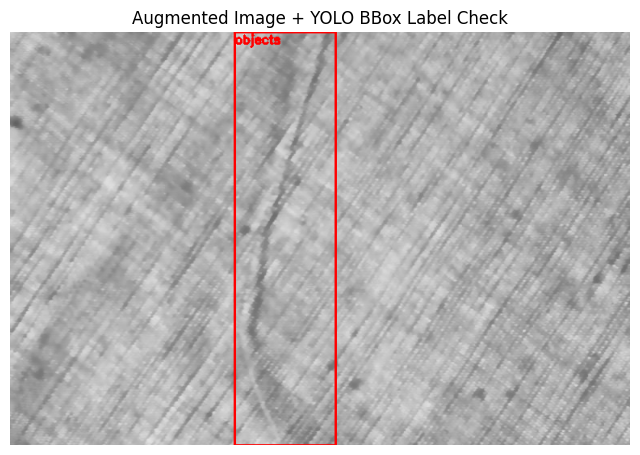

Image: /content/tilda_yolov8_detect/train/images/c1r3e4n41_jpg.rf.f1142a16820283c3cb8bc85007fbacf6_vflip.jpg
Label: /content/tilda_yolov8_detect/train/labels/c1r3e4n41_jpg.rf.f1142a16820283c3cb8bc85007fbacf6_vflip.txt


In [11]:
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np

class_names = {
    0: "hole",
    1: "objects",
    2: "oil spot",
    3: "thread error"
}


def draw_yolo_bboxes(image_path, label_path, class_names):
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    h, w = image_rgb.shape[:2]

    if label_path.exists():
        lines = label_path.read_text().strip().splitlines()
    else:
        lines = []

    for line in lines:
        values = line.split()

        if len(values) != 5:
            continue

        class_id = int(float(values[0]))
        x, y, bw, bh = map(float, values[1:])

        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)

        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)

        label = class_names.get(class_id, str(class_id))
        cv2.putText(
            image_rgb,
            label,
            (x1, max(y1 - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            2
        )

    return image_rgb


aug_images = (
    list(train_image_dir.glob("*hflip*")) +
    list(train_image_dir.glob("*vflip*")) +
    list(train_image_dir.glob("*rot180*"))
)

print("Augmented images found:", len(aug_images))

img_path = random.choice(aug_images)
label_path = train_label_dir / f"{img_path.stem}.txt"

result = draw_yolo_bboxes(img_path, label_path, class_names)

plt.figure(figsize=(8, 8))
plt.imshow(result)
plt.title("Augmented Image + YOLO BBox Label Check")
plt.axis("off")
plt.show()

print("Image:", img_path)
print("Label:", label_path)

In [12]:
data_yaml = {
    "path": str(detect_dataset),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": {
        0: "hole",
        1: "objects",
        2: "oil spot",
        3: "thread error"
    }
}

yaml_path = detect_dataset / "data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(open(yaml_path).read())

path: /content/tilda_yolov8_detect
train: train/images
val: valid/images
test: test/images
names:
  0: hole
  1: objects
  2: oil spot
  3: thread error



In [13]:
model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=150,
    imgsz=416,
    batch=8,
    device=0 if torch.cuda.is_available() else "cpu",

    # online augmentation
    mosaic=0.3,
    scale=0.3,
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    degrees=10,

    patience=30,
    close_mosaic=20,

    project="/content/runs",
    name="yolov8n_detect_tilda_final"
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/tilda_yolov8_detect/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.3, multi_scale=0.0, name=yolov8n_detect_tilda_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [14]:
best_models = list(Path("/content/runs").glob("**/weights/best.pt"))

print("Found best.pt files:")
for p in best_models:
    print(p)

best_model_path = sorted(best_models, key=lambda p: p.stat().st_mtime)[-1]

print("\nUsing latest model:")
print(best_model_path)

Found best.pt files:
/content/runs/yolov8n_detect_tilda_final/weights/best.pt

Using latest model:
/content/runs/yolov8n_detect_tilda_final/weights/best.pt


In [15]:
yolo_model = YOLO(str(best_model_path))

print("Loaded YOLOv8 detection model:")
print(best_model_path)

Loaded YOLOv8 detection model:
/content/runs/yolov8n_detect_tilda_final/weights/best.pt


In [16]:
metrics = yolo_model.val(
    data=str(yaml_path),
    imgsz=416,
    device=0 if torch.cuda.is_available() else "cpu"
)

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP@50:", metrics.box.map50)
print("mAP@50-95:", metrics.box.map)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2051.9±784.5 MB/s, size: 92.9 KB)
val: Scanning /content/tilda_yolov8_detect/valid/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 28.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9it/s 2.6s
                   all         80        103      0.812      0.772      0.853      0.553
                  hole         23         25      0.907       0.92      0.934      0.579
               objects         19         25      0.705        0.8      0.867      0.567
              oil spot         19         24      0.948      0.833      0.966      0.693
          thread error         19         29      0.689      0.535      0.646      0.374
Speed: 1.9ms preprocess, 4.6ms inference, 

In [17]:
results_table = pd.DataFrame({
    "Metric": ["Precision", "Recall", "mAP@50", "mAP@50-95"],
    "YOLOv8n Detection": [
        round(metrics.box.mp, 3),
        round(metrics.box.mr, 3),
        round(metrics.box.map50, 3),
        round(metrics.box.map, 3)
    ]
})

display(results_table)

results_table.to_csv("/content/yolov8n_detection_results.csv", index=False)

print("Saved at: /content/yolov8n_detection_results.csv")

,Metric,YOLOv8n Detection
0,Precision,0.812
1,Recall,0.772
2,mAP@50,0.853
3,mAP@50-95,0.553


Saved at: /content/yolov8n_detection_results.csv


In [18]:
!wget -q -O /content/sam_vit_h_4b8939.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

In [19]:
from segment_anything import sam_model_registry, SamPredictor

sam_device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_h"](
    checkpoint="/content/sam_vit_h_4b8939.pth"
)

sam.to(sam_device)

predictor = SamPredictor(sam)

print("SAM loaded on:", sam_device)

SAM loaded on: cuda


Selected image: /content/tilda_yolov8_detect/test/images/c1r1e3n31_jpg.rf.14ba4192de4d2afdfe5b1850b3209653.jpg
Detected objects: 2


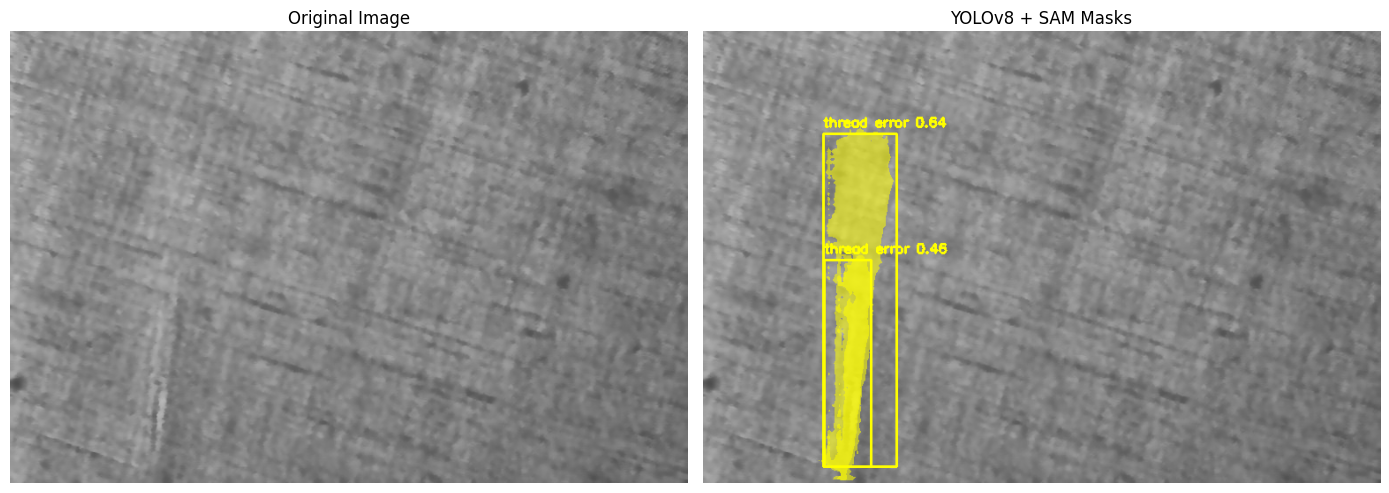

In [20]:
test_dir = detect_dataset / "test" / "images"

image_paths = (
    list(test_dir.glob("*.jpg")) +
    list(test_dir.glob("*.jpeg")) +
    list(test_dir.glob("*.png"))
)

image_path = random.choice(image_paths)
print("Selected image:", image_path)

# Read once into RAM, reuse everywhere
image_bgr = cv2.imread(str(image_path))
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Pass array directly — no second disk read
yolo_results = yolo_model.predict(
    source=image_bgr,
    imgsz=416,
    conf=0.25,
    device=0 if torch.cuda.is_available() else "cpu",
    verbose=False
)

r = yolo_results[0]
boxes   = r.boxes.xyxy.cpu().numpy()
classes = r.boxes.cls.cpu().numpy().astype(int)
scores  = r.boxes.conf.cpu().numpy()

print("Detected objects:", len(boxes))

predictor.set_image(image_rgb)

overlay = image_rgb.copy()

class_colors = {
    0: (255, 0, 0),
    1: (0, 255, 0),
    2: (0, 0, 255),
    3: (255, 255, 0)
}

for box, cls_id, score in zip(boxes, classes, scores):
    x1, y1, x2, y2 = box.astype(int)
    input_box = np.array([x1, y1, x2, y2])

    masks, sam_scores, _ = predictor.predict(
        box=input_box,
        multimask_output=True
    )
    best_mask = masks[np.argmax(sam_scores)]

    color = class_colors.get(cls_id, (255, 255, 255))
    color_np = np.array(color, dtype=np.uint8)
    overlay[best_mask] = (0.45 * overlay[best_mask] + 0.55 * color_np).astype(np.uint8)

    cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
    label = f"{r.names[cls_id]} {score:.2f}"
    cv2.putText(overlay, label, (x1, max(y1 - 8, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1); plt.imshow(image_rgb); plt.title("Original Image"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(overlay);   plt.title("YOLOv8 + SAM Masks"); plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
def mask_to_polygon(mask, img_w, img_h, epsilon_factor=0.005):
    mask = mask.astype(np.uint8) * 255

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    largest_contour = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(largest_contour)

    if area < 10:
        return None

    epsilon = epsilon_factor * cv2.arcLength(largest_contour, True)
    approx = cv2.approxPolyDP(largest_contour, epsilon, True)

    if len(approx) < 3:
        return None

    polygon = []

    for point in approx:
        x, y = point[0]

        x_norm = x / img_w
        y_norm = y / img_h

        x_norm = min(max(x_norm, 0), 1)
        y_norm = min(max(y_norm, 0), 1)

        polygon.extend([x_norm, y_norm])

    return polygon

In [22]:
output_label_dir = Path("/content/yolov8_detection_sam_polygon_outputs")
output_label_dir.mkdir(parents=True, exist_ok=True)

test_image_paths = (
    list(test_dir.glob("*.jpg")) +
    list(test_dir.glob("*.jpeg")) +
    list(test_dir.glob("*.png"))
)

for image_path in tqdm(test_image_paths, desc="Generating YOLO + SAM polygon outputs"):
    # Read once, reuse for both YOLO and SAM
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        continue

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    img_h, img_w = image_rgb.shape[:2]

    # Pass array — no second disk read
    yolo_results = yolo_model.predict(
        source=image_bgr,
        imgsz=416,
        conf=0.25,
        device=0 if torch.cuda.is_available() else "cpu",
        verbose=False
    )

    r = yolo_results[0]
    boxes   = r.boxes.xyxy.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy().astype(int)

    predictor.set_image(image_rgb)

    polygon_lines = []

    for box, cls_id in zip(boxes, classes):
        masks, sam_scores, _ = predictor.predict(
            box=box.astype(int),
            multimask_output=True
        )
        best_mask = masks[np.argmax(sam_scores)]
        polygon = mask_to_polygon(best_mask, img_w, img_h)
        if polygon is None:
            continue
        polygon_str = " ".join([f"{p:.6f}" for p in polygon])
        polygon_lines.append(f"{cls_id} {polygon_str}")

    output_txt = output_label_dir / f"{image_path.stem}.txt"
    output_txt.write_text("\n".join(polygon_lines))

print("Saved YOLO + SAM polygon outputs at:", output_label_dir)

Generating YOLO + SAM polygon outputs: 100%|██████████| 40/40 [01:24<00:00,  2.10s/it]

Saved YOLO + SAM polygon outputs at: /content/yolov8_detection_sam_polygon_outputs


Polygon label files found: 40
Valid image-label pairs: 40
Selected image: /content/tilda_yolov8_detect/test/images/c1r3e2n3_jpg.rf.cf5910d5ae748b69618d1fb126f353d1.jpg
Selected polygon label: /content/yolov8_detection_sam_polygon_outputs/c1r3e2n3_jpg.rf.cf5910d5ae748b69618d1fb126f353d1.txt


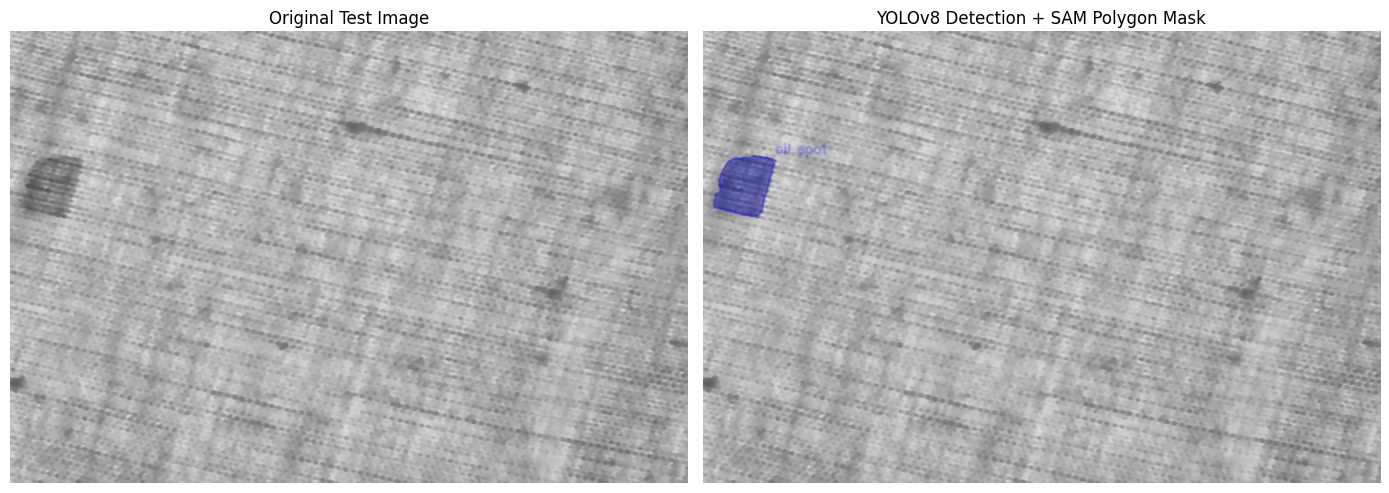

In [23]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
test_dir = Path("/content/tilda_yolov8_detect/test/images")
output_label_dir = Path("/content/yolov8_detection_sam_polygon_outputs")

# Class names
class_names = {
    0: "hole",
    1: "objects",
    2: "oil spot",
    3: "thread error"
}

# Colors for each class in RGB
class_colors = {
    0: (255, 0, 0),      # red
    1: (0, 255, 0),      # green
    2: (0, 0, 255),      # blue
    3: (255, 255, 0)     # yellow
}


def find_matching_image(label_path, image_dir):
    """
    Finds image file matching polygon txt name.
    """
    for ext in [".jpg", ".jpeg", ".png"]:
        img_path = image_dir / f"{label_path.stem}{ext}"
        if img_path.exists():
            return img_path
    return None


def visualize_yolo_sam_polygon(image_path, label_path):
    """
    Visualizes YOLO + SAM polygon output on image.
    YOLO-SAM polygon format:
    class_id x1 y1 x2 y2 x3 y3 ...
    """
    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    h, w = image_rgb.shape[:2]

    overlay = image_rgb.copy()
    boundary = image_rgb.copy()

    if not label_path.exists():
        raise FileNotFoundError(f"Label file not found: {label_path}")

    lines = label_path.read_text().strip().splitlines()

    if len(lines) == 0:
        print("No polygon found in:", label_path)

    for line in lines:
        values = line.split()

        if len(values) < 7:
            print("Skipping invalid polygon line:", line)
            continue

        class_id = int(float(values[0]))
        coords = list(map(float, values[1:]))

        polygon = []

        for i in range(0, len(coords), 2):
            x = int(coords[i] * w)
            y = int(coords[i + 1] * h)

            x = max(0, min(x, w - 1))
            y = max(0, min(y, h - 1))

            polygon.append([x, y])

        polygon = np.array(polygon, dtype=np.int32)

        color = class_colors.get(class_id, (255, 255, 255))

        # Fill polygon mask
        cv2.fillPoly(overlay, [polygon], color)

        # Draw polygon boundary
        cv2.polylines(boundary, [polygon], True, color, 2)

        # Put class label near first polygon point
        x_text, y_text = polygon[0]

        label = class_names.get(class_id, str(class_id))

        cv2.putText(
            boundary,
            label,
            (x_text, max(y_text - 8, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

    # Blend mask with image
    mask_result = cv2.addWeighted(image_rgb, 0.65, overlay, 0.35, 0)

    # Add boundary on blended mask
    final_result = cv2.addWeighted(mask_result, 0.8, boundary, 0.2, 0)

    return image_rgb, final_result


# Get polygon label files
label_files = list(output_label_dir.glob("*.txt"))

print("Polygon label files found:", len(label_files))

if len(label_files) == 0:
    raise FileNotFoundError("No polygon .txt files found. Run the YOLO + SAM polygon generation cell first.")

# Select random label that has matching image
valid_pairs = []

for label_path in label_files:
    image_path = find_matching_image(label_path, test_dir)
    if image_path is not None:
        valid_pairs.append((image_path, label_path))

print("Valid image-label pairs:", len(valid_pairs))

if len(valid_pairs) == 0:
    raise FileNotFoundError("No matching images found for polygon labels.")

# Pick random sample
image_path, label_path = random.choice(valid_pairs)

print("Selected image:", image_path)
print("Selected polygon label:", label_path)

original, result = visualize_yolo_sam_polygon(image_path, label_path)

# Display
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Test Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title("YOLOv8 Detection + SAM Polygon Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

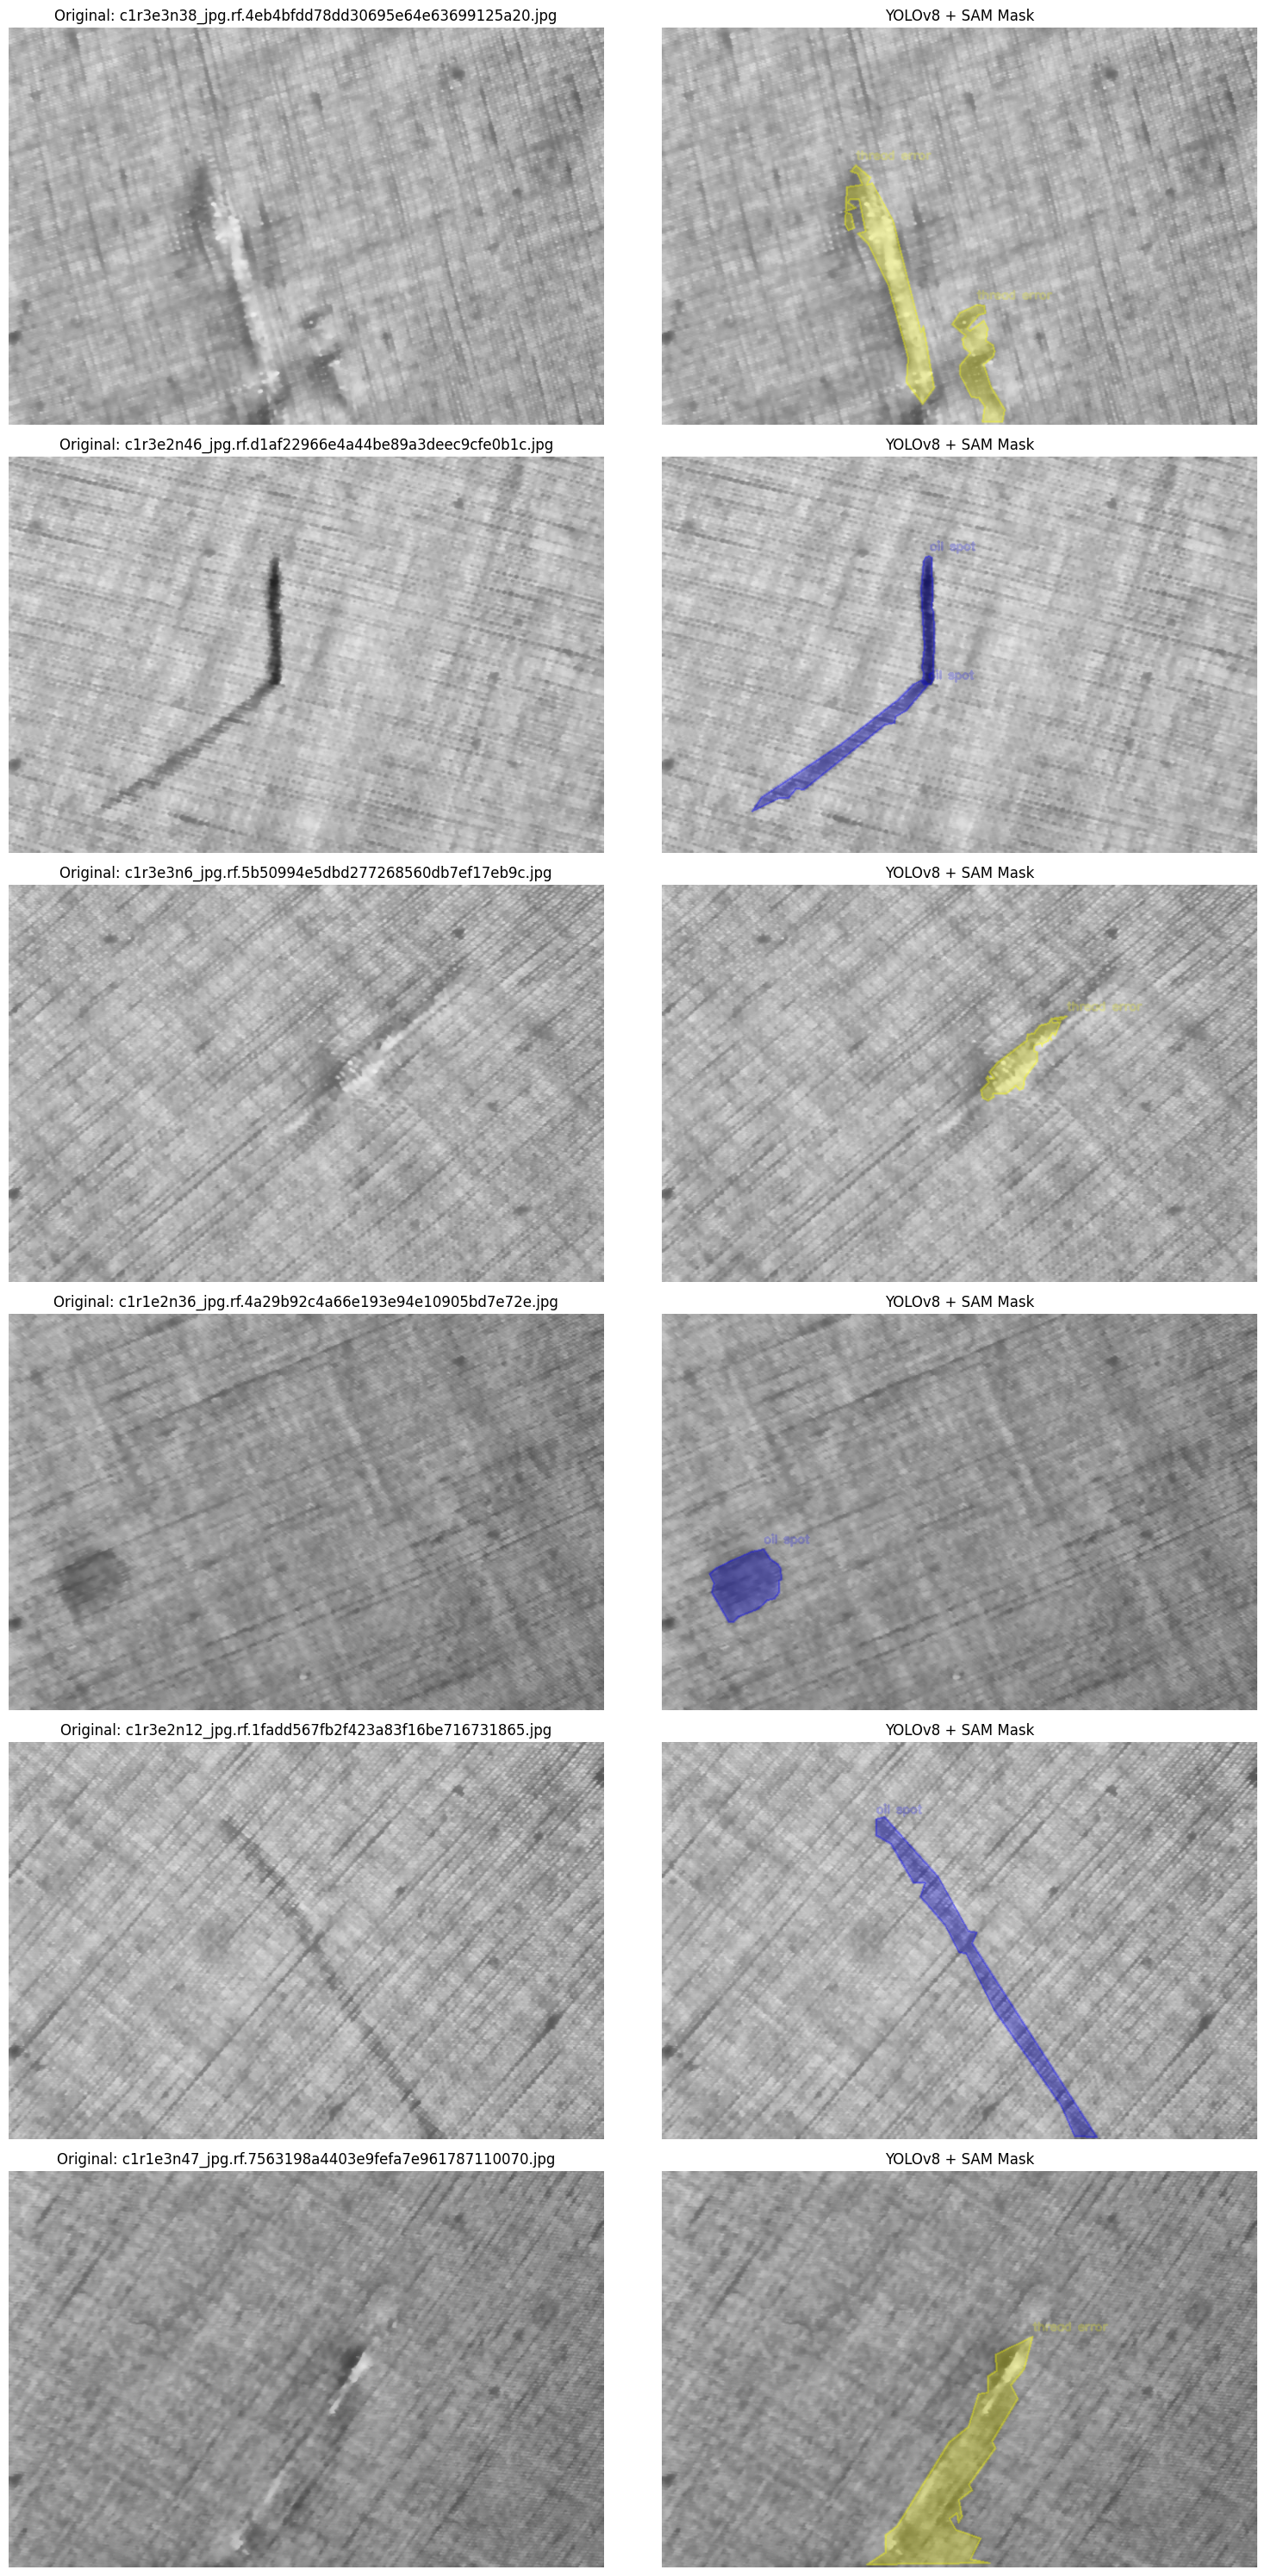

In [24]:
def visualize_multiple_yolo_sam_outputs(valid_pairs, n=6):
    n = min(n, len(valid_pairs))

    samples = random.sample(valid_pairs, n)

    plt.figure(figsize=(16, 5 * n))

    for idx, (image_path, label_path) in enumerate(samples):
        original, result = visualize_yolo_sam_polygon(image_path, label_path)

        plt.subplot(n, 2, idx * 2 + 1)
        plt.imshow(original)
        plt.title(f"Original: {image_path.name}")
        plt.axis("off")

        plt.subplot(n, 2, idx * 2 + 2)
        plt.imshow(result)
        plt.title("YOLOv8 + SAM Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_multiple_yolo_sam_outputs(valid_pairs, n=6)

Pre-loading 40 images into RAM...
Loaded 40 images.

Warming up GPU...
Warmup done.

   YOLOv8n Detection — FPS Benchmark
  Images tested    : 40
  Runs per image   : 3 (median taken)
  Avg latency      : 18.79 ms
  Average FPS      : 53.2
  Best FPS         : 127.3
  Worst FPS        : 18.6


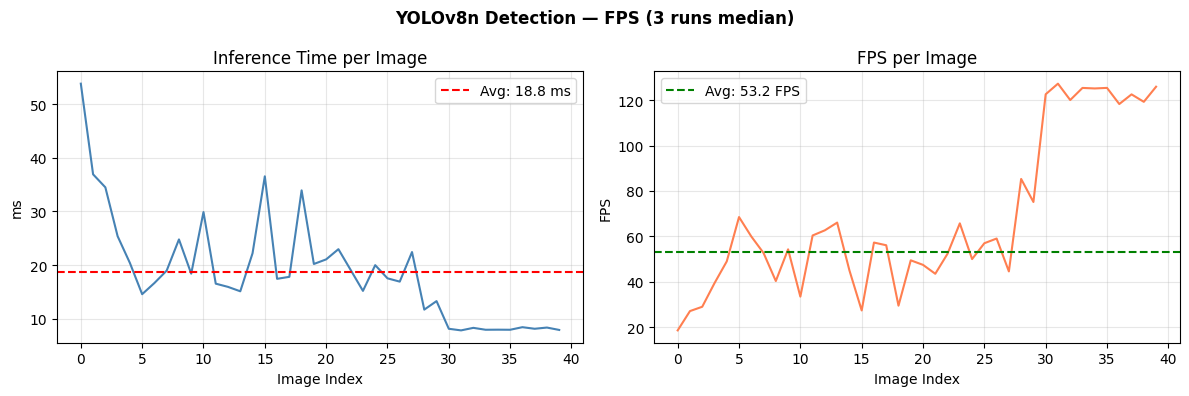

In [25]:
import time
import torch
import cv2
import numpy as np
from pathlib import Path

test_dir = Path("/content/tilda_yolov8_detect/test/images")

test_image_paths = (
    list(test_dir.glob("*.jpg")) +
    list(test_dir.glob("*.jpeg")) +
    list(test_dir.glob("*.png"))
)

device = 0 if torch.cuda.is_available() else "cpu"

# Step 1 — pre-load all images into RAM so disk I/O is never inside the timer
print(f"Pre-loading {len(test_image_paths)} images into RAM...")
loaded_images = []
for p in test_image_paths:
    img = cv2.imread(str(p))
    if img is not None:
        loaded_images.append(img)
print(f"Loaded {len(loaded_images)} images.\n")

# Step 2 — warmup (10 runs so CUDA kernels compile before timing starts)
print("Warming up GPU...")
for img in loaded_images[:10]:
    yolo_model.predict(source=img, imgsz=416, conf=0.25, device=device, verbose=False)
print("Warmup done.\n")

# Step 3 — measure: 3 runs per image, take median to remove spikes
all_times = []

for img in loaded_images:
    run_times = []
    for _ in range(3):
        torch.cuda.synchronize()        # wait for GPU before starting clock
        t0 = time.perf_counter()

        yolo_model.predict(source=img, imgsz=416, conf=0.25, device=device, verbose=False)

        torch.cuda.synchronize()        # wait for GPU before stopping clock
        t1 = time.perf_counter()
        run_times.append((t1 - t0) * 1000)

    all_times.append(np.median(run_times))   # median of 3 removes outliers

times   = np.array(all_times)
avg_ms  = times.mean()
avg_fps = 1000 / avg_ms

print("=" * 45)
print("   YOLOv8n Detection — FPS Benchmark")
print("=" * 45)
print(f"  Images tested    : {len(times)}")
print(f"  Runs per image   : 3 (median taken)")
print(f"  Avg latency      : {avg_ms:.2f} ms")
print(f"  Average FPS      : {avg_fps:.1f}")
print(f"  Best FPS         : {1000 / times.min():.1f}")
print(f"  Worst FPS        : {1000 / times.max():.1f}")
print("=" * 45)

import matplotlib.pyplot as plt

fps_per_image = 1000 / times

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(times, color="steelblue", linewidth=1.5)
plt.axhline(avg_ms, color="red", linestyle="--", label=f"Avg: {avg_ms:.1f} ms")
plt.xlabel("Image Index")
plt.ylabel("ms")
plt.title("Inference Time per Image")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(fps_per_image, color="coral", linewidth=1.5)
plt.axhline(avg_fps, color="green", linestyle="--", label=f"Avg: {avg_fps:.1f} FPS")
plt.xlabel("Image Index")
plt.ylabel("FPS")
plt.title("FPS per Image")
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle("YOLOv8n Detection — FPS (3 runs median)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/detection_fps.png", dpi=150)
plt.show()